In [ ]:
import os
import warnings

import numpy as np
import pandas as pd

from mfsindy.cases.hopf import HopfIntraTrajectoryGLSConfig, run_hopf_intra_trajectory_gls_experiment
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")

cfg = HopfIntraTrajectoryGLSConfig(
    n_runs=5,         
    t0=0.0,
    t1=10.0,
    dt=1e-3,
    mu=1.0,
    omega=1.0, #(also 10 is cool)
    sigma0=1e-2,
    alpha=0.25,
    poly_degree=3,
    derivative_order=1,
    H_xt=0.01,
    K=5000,
    p=2,
    include_bias=False,
    stlsq_threshold=0.5,
    n_ensemble_models=20,
    seed_base=0,
    results_dir="results",
    results_filename="hopf_weighted_errors.csv",
)


# Hopf Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

The Hopf oscillator is governed by

$$
\begin{aligned}
\dot{x} &= \mu x - \omega y - (x^2 + y^2)x, \\
\dot{y} &= \omega x + \mu y - (x^2 + y^2)y.
\end{aligned}
$$

We use fixed values of the bifurcation parameter $\mu=1$ and angular frequency $\omega=1$ for all simulations.

Let $U=(x,y)^\top$ denote the system state. We model additive perturbation error by adding a zero-mean random noise term $\epsilon$ to $U$, so that
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$
The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0,
\qquad
\mathrm{Var}(\epsilon) \propto \alpha^2 \|U\|^2,
$$
where $\alpha > 0$ controls the noise amplitude.

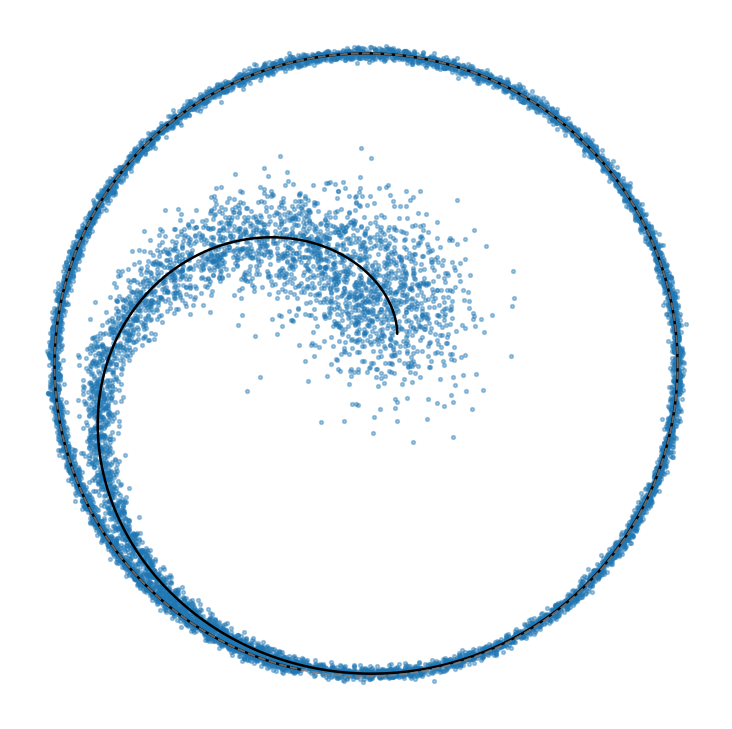

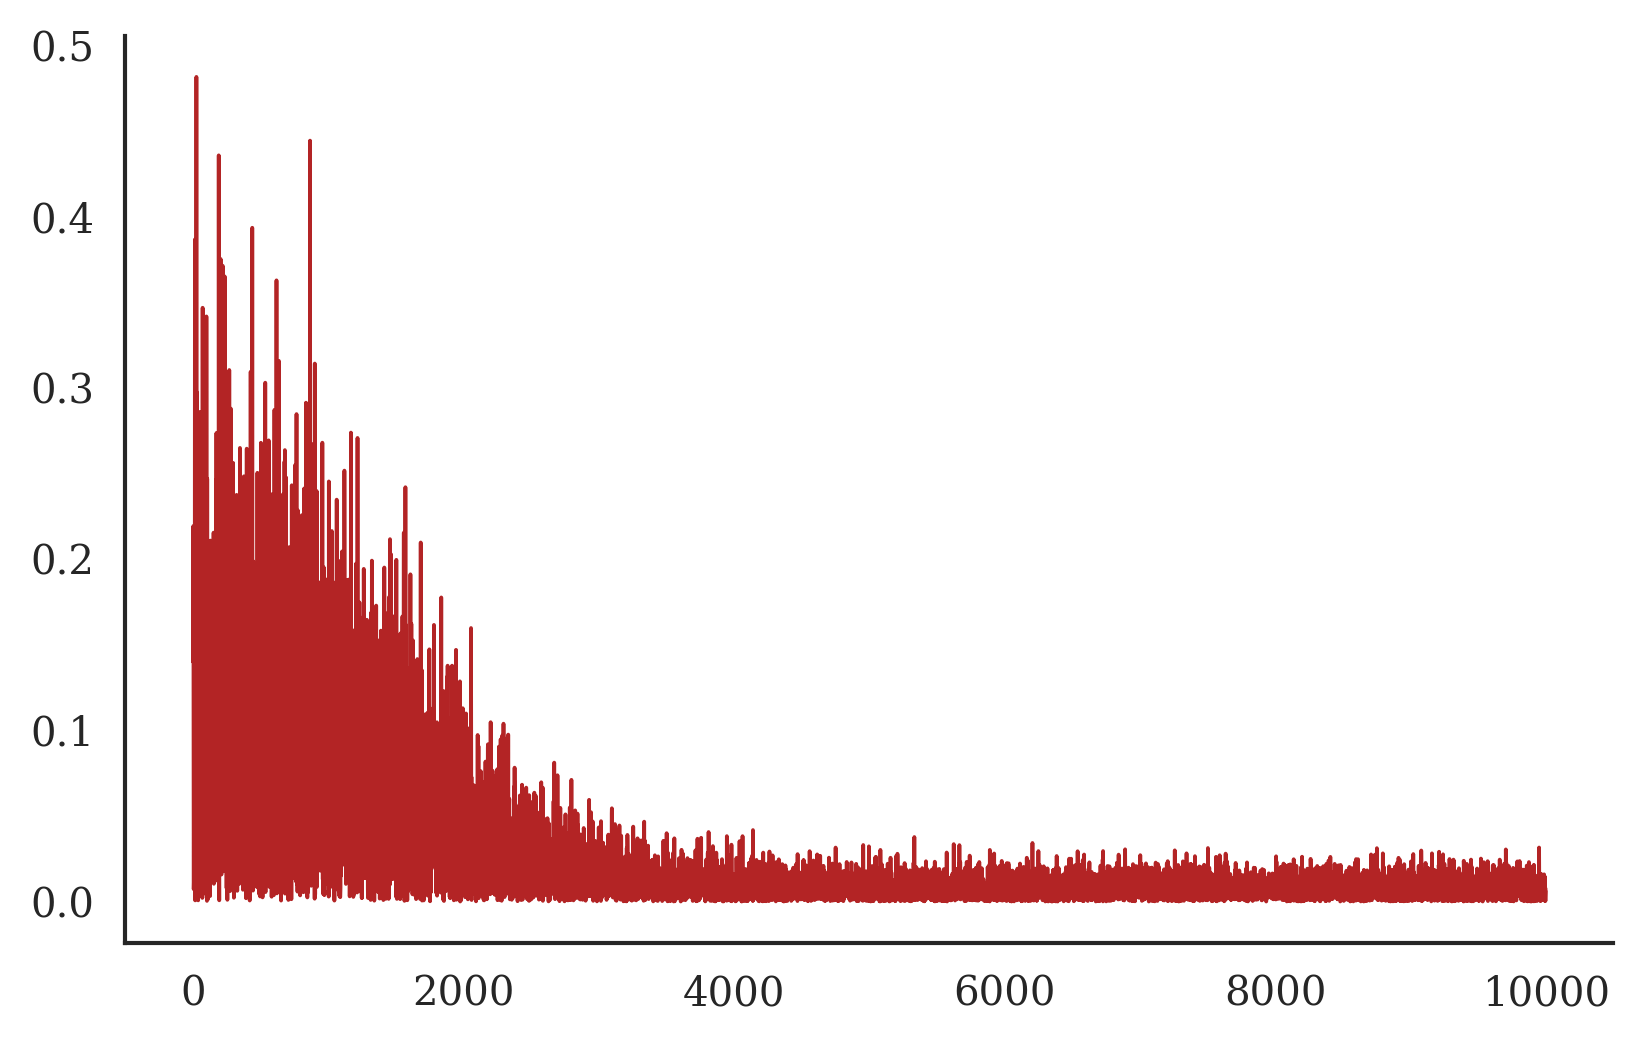

In [2]:
from mfsindy.cases.hopf import generate_hopf_trajectory
from mfsindy.cases.hopf_plots import plot_trajectories_additive_noise, plot_residuals

u0 = np.array([0.1,0.1])
t, X_true = generate_hopf_trajectory(
    u0=u0,
    noise_level=0.0,
    seed=0,
    T=10,
    mu=1,
    omega=1
)
X_noisy = plot_trajectories_additive_noise(x_true=X_true,alpha=0.25)
plot_residuals(X_true, X_noisy)


In [3]:
print(f"Running heteroscedastic Hopf GLS experiment with {cfg.n_runs} runs.")

df_errors, L1_errors, L0_errors = run_hopf_intra_trajectory_gls_experiment(cfg)


Running heteroscedastic Hopf GLS experiment with 5 runs.


Monte Carlo Hopf GLS: 100%|██████████| 5/5 [00:52<00:00, 10.50s/it]


In [4]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

methods = ["No weighting", "Variance GLS", "Ones GLS"]

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nL1 errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L1_errors[m]))

print("\nL0 support errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L0_errors[m]))



L1 errors (first few, reloaded from CSV):
No weighting 0.3379281519479168
Variance GLS 0.0271967388080715
Ones GLS 0.1772682190607415

L0 support errors (first few, reloaded from CSV):
No weighting 0.75
Variance GLS 0.0
Ones GLS 0.375


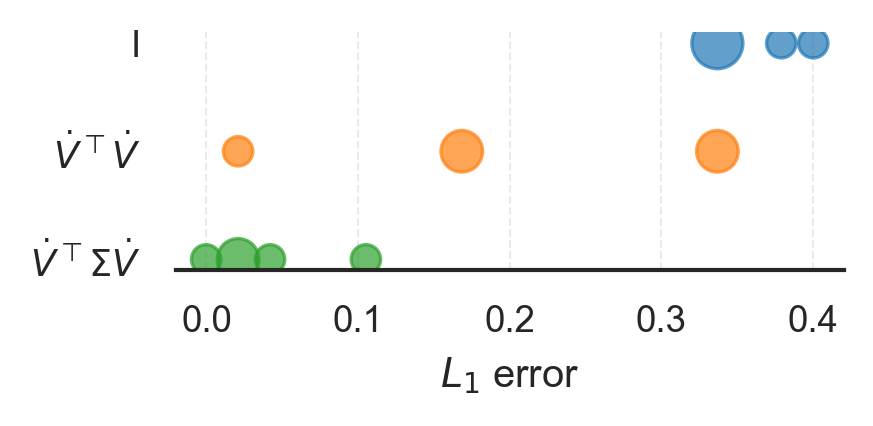

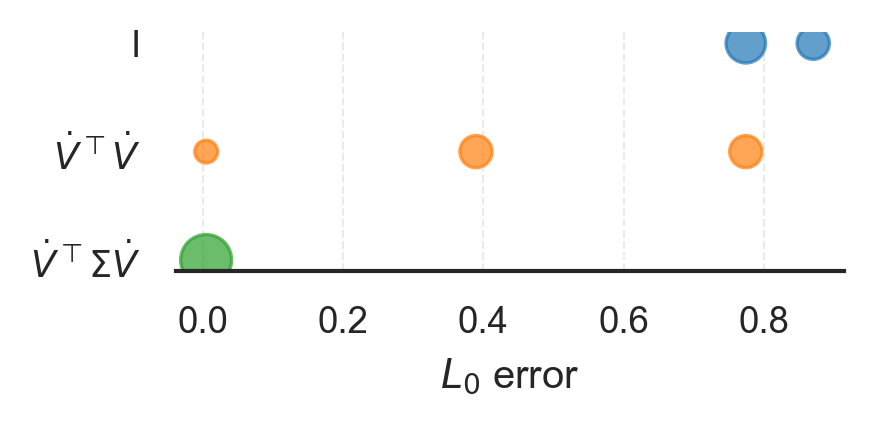

In [5]:
# Bubble-hist plots for L1 and L0
# ---------------------------------------------------------------------

method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}^\top\Sigma\dot{V}$",r"$\dot{V}^\top\dot{V}$","I"]

bubble_hist(
    errors_dict=L1_errors,
    xlabel=r"$L_1$ error",
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels
)

bubble_hist(
    errors_dict=L0_errors,
    xlabel=r"$L_0$ error",
    n_bins=10,
    models_order=methods,
    colors=method_colors,
    labels=labels
)
